##DATASET

El dataset utilizado corresponde a mantenimiento predictivo:

- **Dataset:** NASA Turbofan Jet Engine Data Set
- **Origen:** https://www.kaggle.com/datasets/behrad3d/nasa-cmaps
- **Drive Origen Proyecto:** https://drive.google.com/drive/folders/1A2pL0b9r4Oq3NKc6tLkVxBL7za9TLV9w?usp=drive_link


Para el desarrollo de este proyecto se ha optado por utilizar un dataset
de tipo regresion, ya que el objetivo principal es predecir una variable
numerica continua.

Esta elección se encuentra alineada con aplicaciones reales en entornos
industriales, particularmente en la empresa donde actualmente trabajo.

A futuro, se busca aplicar este enfoque en la predicción de mantenimiento
predictivo, específicamente en la estimacion de la vida util de equipos
críticos como baterías de UPS (Sistemas de Alimentación Ininterrumpida).

## CONTEXTO DEL NEGOCIO

En la industrias aeronautica, la energia y las fallas en equipos generan altos costos operativos y riesgos.

El mantenimiento tradicional (preventivo o correctivo) no siempre es eficiente:
- Preventivo: puede generar costos innecesarios
- Correctivo: implica fallas inesperadas

Por ello surge el mantenimiento predictivo, que permite anticipar fallas
utilizando datos historicos y sensores en tiempo real.


##OBJETIVO GENERAL

Desarrollar un modelo que permita estimar la vida util restante de motores
a partir de datos de sensores, con el fin de anticipar fallas y optimizar
la toma de decisiones en mantenimiento.

##OBJETIVOS ESPECÍFICOS

1. Analizar el comportamiento de los sensores a lo largo del tiempo
2. Detectar patrones asociados a la degradacion de los motores
3. Identificar variables relevantes para la predicción
4. Construir una variable objetivo (vida util)
5. Preparar los datos para futuros modelos de Machine Learning

##AUDIENCIA

- Gerentes de operaciones
- Equipos de mantenimiento
- Ingenieros industriales
- Analistas de datos

Este analisis permite tomar decisiones basadas en datos para reducir costos
y evitar fallas críticas.

##PREGUNTAS / HIPOTESIS

1. Como evoluciona la degradacion de los motores?
2. Existen sensores que anticipan fallas?
3. Que variables tienen mayor relacion con la vida util?
4. Se pueden detectar patrones de desgaste antes de la falla?

##CARGA de DATOS

In [206]:
#Importando Librerias a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Asignadole la la ubicacion del dataset a la variable url, se utiliza el archivo alojado en GitHub
url = "https://raw.githubusercontent.com/Diegoagodoy/Data_Science_Machine_Learning_Ciencia_de_Datos/main/train_FD001.txt"

#Carga del dataset
df = pd.read_csv(url, sep=r"\s+", header=None)

Dado que el archivo es un txt no contiene separadores tradicionales (como comas), se utiliza sep=r"\s+" para indicar que los valores están separados por uno o más espacios.

##Exploración inicial

In [207]:
#Dimensiones del dataset (filas, columnas)
df.shape


(20631, 26)

In [208]:
# Primeras 5 filas
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [209]:
# Ultimas 5 filas
df.tail()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [210]:
# Muestra aleatoria
df.sample(10)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
1517,7,214,0.0022,0.0002,100.0,518.67,642.87,1586.43,1415.25,14.62,...,521.44,2388.13,8147.08,8.4723,0.03,395,2388,100.0,38.66,23.2265
19925,97,38,-0.0000,-0.0004,100.0,518.67,642.82,1585.17,1408.19,14.62,...,521.44,2388.03,8127.90,8.3936,0.03,390,2388,100.0,38.90,23.3656
18270,90,45,0.0012,0.0001,100.0,518.67,642.10,1588.57,1395.36,14.62,...,521.95,2388.10,8133.53,8.4314,0.03,391,2388,100.0,39.01,23.3888
8452,44,8,0.0023,0.0004,100.0,518.67,642.09,1582.29,1400.99,14.62,...,522.43,2388.00,8151.03,8.4175,0.03,393,2388,100.0,39.00,23.6127
17556,86,217,-0.0001,0.0003,100.0,518.67,643.11,1598.84,1419.03,14.62,...,520.76,2388.14,8149.27,8.4794,0.03,393,2388,100.0,38.62,23.1153
19203,94,193,0.0016,-0.0002,100.0,518.67,643.14,1585.94,1410.26,14.62,...,520.96,2388.12,8154.22,8.5017,0.03,394,2388,100.0,38.76,23.2833
14173,71,44,-0.0030,0.0002,100.0,518.67,642.48,1586.16,1402.20,14.62,...,521.97,2388.08,8130.67,8.4096,0.03,392,2388,100.0,38.86,23.3725
5022,25,143,0.0003,-0.0002,100.0,518.67,642.71,1593.85,1409.66,14.62,...,521.37,2388.06,8141.76,8.4357,0.03,394,2388,100.0,38.71,23.1922
5274,26,165,-0.0050,-0.0003,100.0,518.67,642.94,1602.91,1423.98,14.62,...,520.95,2388.19,8162.95,8.4769,0.03,395,2388,100.0,38.60,23.1424
14677,73,127,-0.0017,0.0001,100.0,518.67,643.23,1590.17,1417.42,14.62,...,520.63,2388.15,8119.54,8.4700,0.03,394,2388,100.0,38.58,23.2371


In [211]:
# Nombres de columnas actuales
df.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25],
      dtype='int64')

In [212]:
# Informacion general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       20631 non-null  int64  
 1   1       20631 non-null  int64  
 2   2       20631 non-null  float64
 3   3       20631 non-null  float64
 4   4       20631 non-null  float64
 5   5       20631 non-null  float64
 6   6       20631 non-null  float64
 7   7       20631 non-null  float64
 8   8       20631 non-null  float64
 9   9       20631 non-null  float64
 10  10      20631 non-null  float64
 11  11      20631 non-null  float64
 12  12      20631 non-null  float64
 13  13      20631 non-null  float64
 14  14      20631 non-null  float64
 15  15      20631 non-null  float64
 16  16      20631 non-null  float64
 17  17      20631 non-null  float64
 18  18      20631 non-null  float64
 19  19      20631 non-null  float64
 20  20      20631 non-null  float64
 21  21      20631 non-null  int64  
 22

In [213]:
# Estadistica
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


- Se realiza una exploración inicial con el objetivo de comprender su estructura.
- Se analizan las dimensiones, se visualizan registros iniciales y finales, y se obtiene una muestra aleatoria.
- Se observa que las columnas no poseen nombres descriptivos, sino índices numéricos asignados automáticamente.
- No se detectan valores nulos en ninguna de las columnas, ya que todas presentan 20.631 valores no nulos.

##DATA WRANGLING (LIMPIEZA)

In [214]:
# Elimina columnas vacias
df = df.dropna(axis=1)

In [215]:
# Verifica duplicados
df.duplicated().sum()

np.int64(0)

In [216]:
# Verifica valores nulos
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


##RENOMBRE de VARIABLES

El dataset original no contiene nombres de columnas, por lo que se asignan
manualmente para facilitar su interpretación.

Se identifican:
- ID del motor
- Ciclo de operacion
- Configuraciones operativas
- Sensores

In [217]:
#Asignacion de nombres de columnas
columnas = [
    'motor_id', 'ciclo',
    'configuracion_operativa_1', 'configuracion_operativa_2', 'configuracion_operativa_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
    'sensor_21'
]
#se le asiganan las columnas adl dataframe
df.columns = columnas

**Variables**
- motor_id = identifica a que motor pertenece cada registro
- ciclo = representa el nivel de uso acumulado del motor
- configuracion_operativa_(1 al 3) = condicion de trabajo
- sensores_(1 al 21) = sensa el motor y dice como esta internamente

In [218]:
# Vemos las primeras 5 filas
df.head()

,motor_id,ciclo,configuracion_operativa_1,configuracion_operativa_2,configuracion_operativa_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [219]:
#resumen estadistico de cada variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
motor_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
ciclo,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
configuracion_operativa_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
configuracion_operativa_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
configuracion_operativa_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


##ANALISIS de OUTLIERS

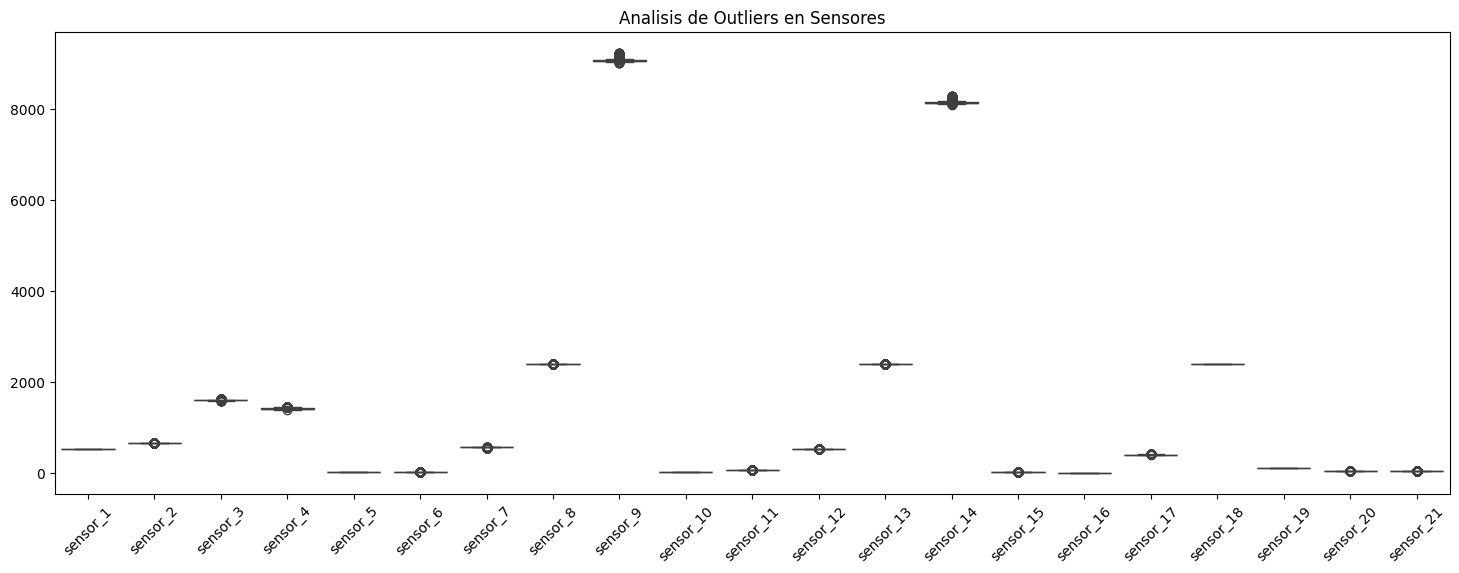

In [220]:
sensores = [col for col in df.columns if 'sensor' in col]

plt.figure(figsize=(18, 6))
sns.boxplot(data=df[sensores])
plt.title("Analisis de Outliers en Sensores")
plt.xticks(rotation=45)
plt.show()

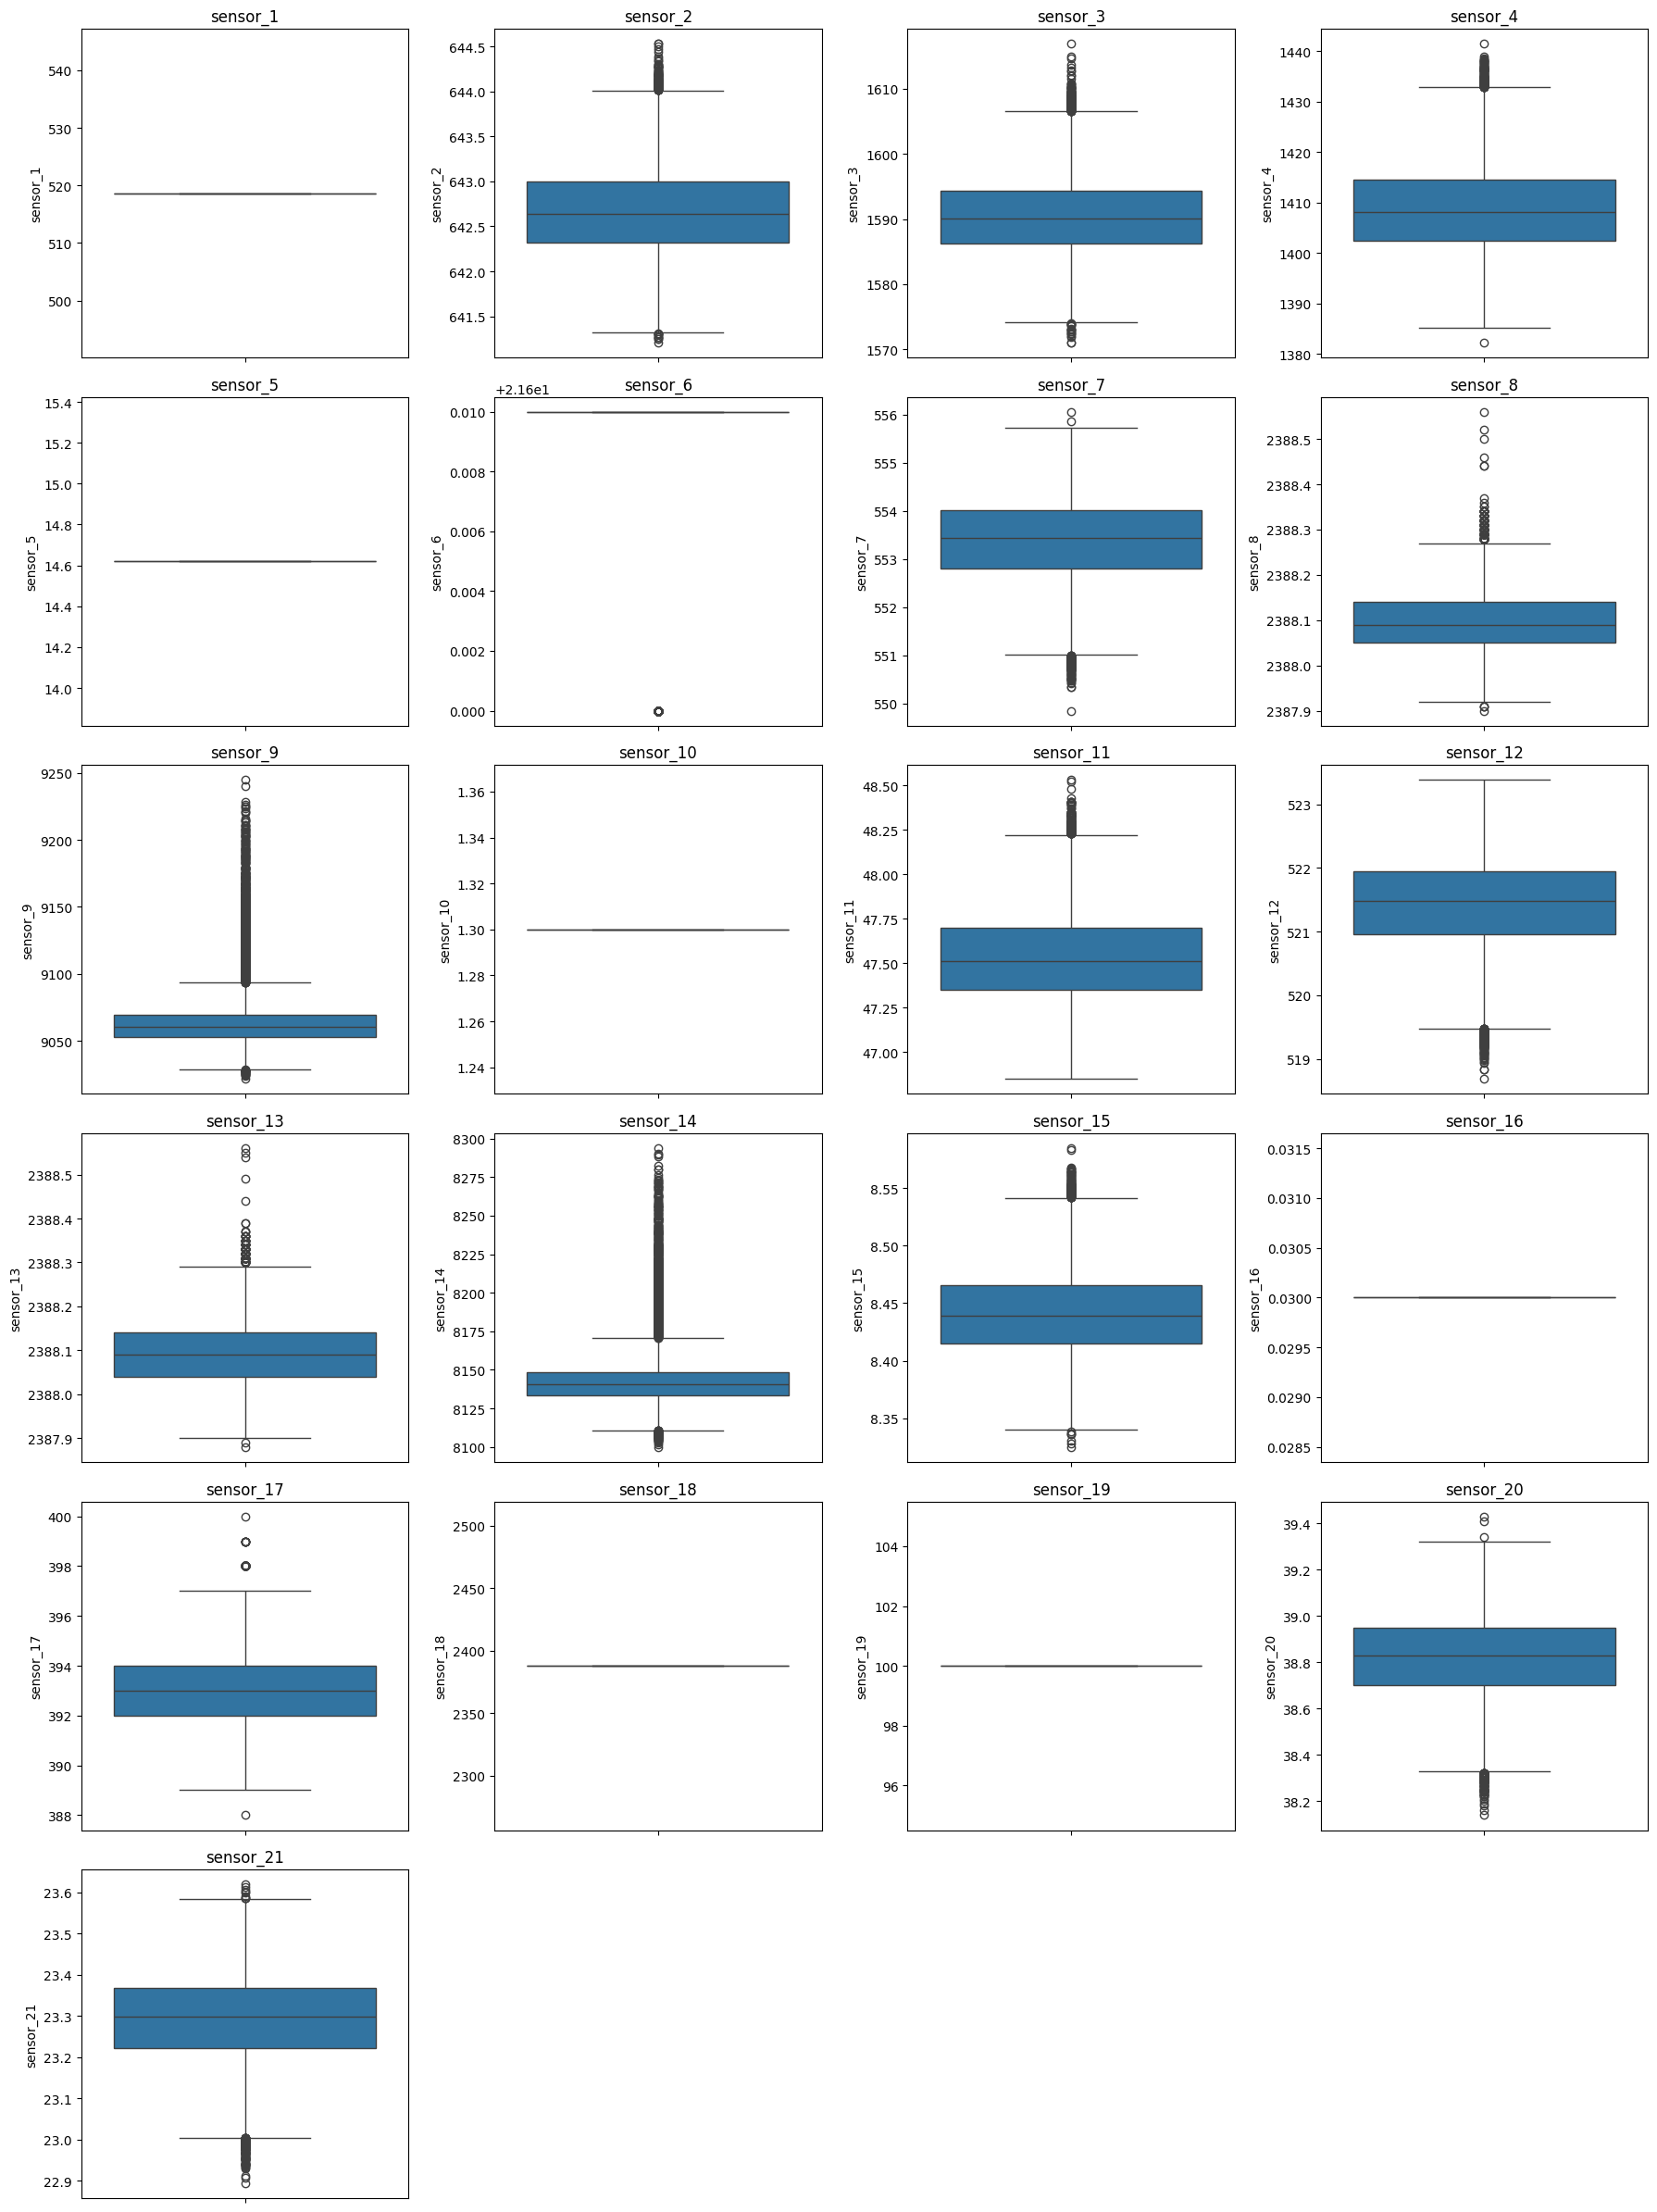

In [221]:
# Seleccionar sensores
sensores = [col for col in df.columns if 'sensor' in col]

# Grilla vista
cols = 4
rows = (len(sensores) // cols) + 1

plt.figure(figsize=(18, rows * 4))

# Loop para graficar todos los sensores
for i, col in enumerate(sensores):
    plt.subplot(rows, cols, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

- Se observan valores no tipicos en varios sensores, lo que podria indicar un desgaste del motor."

##TRATAMIENTO de OUTLIERS

- Se evita la eliminacion masiva de outliers ya que estos pueden representar condiciones reales del motor. En su lugar, se analizan y se consideran dentro del comportamiento del sistema.

##CREACION de VARIABLE OBJETIVO

In [222]:
# Obtencion del ciclo maximo (momento de falla) por motor
max_ciclo = df.groupby('motor_id')['ciclo'].max().reset_index()

# Renombrar columna
max_ciclo.columns = ['motor_id', 'ciclo_max']

# Uniendo con dataset original
df = df.merge(max_ciclo, on='motor_id')

# Calculo de vida util restante (vida_util)
df['vida_util'] = df['ciclo_max'] - df['ciclo']

La "vida_util" se calcula como la diferencia entre el ultimo ciclo registrado y el ciclo actual.

##EDA

**Analisis Univariado**

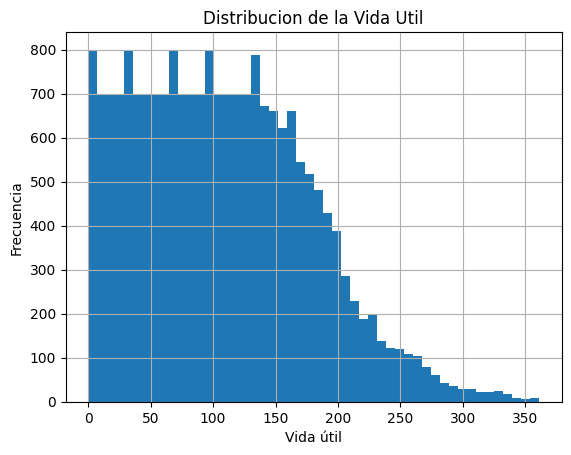

In [223]:
# Distribución de la vida_util
df['vida_util'].hist(bins=50)
plt.title("Distribucion de la Vida Util")
plt.xlabel("Vida útil")
plt.ylabel("Frecuencia")
plt.show()

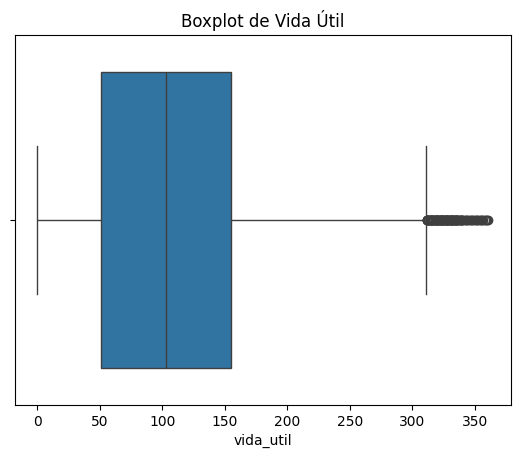

In [224]:
sns.boxplot(x=df['vida_util'])
plt.title("Boxplot de Vida Útil")
plt.show()

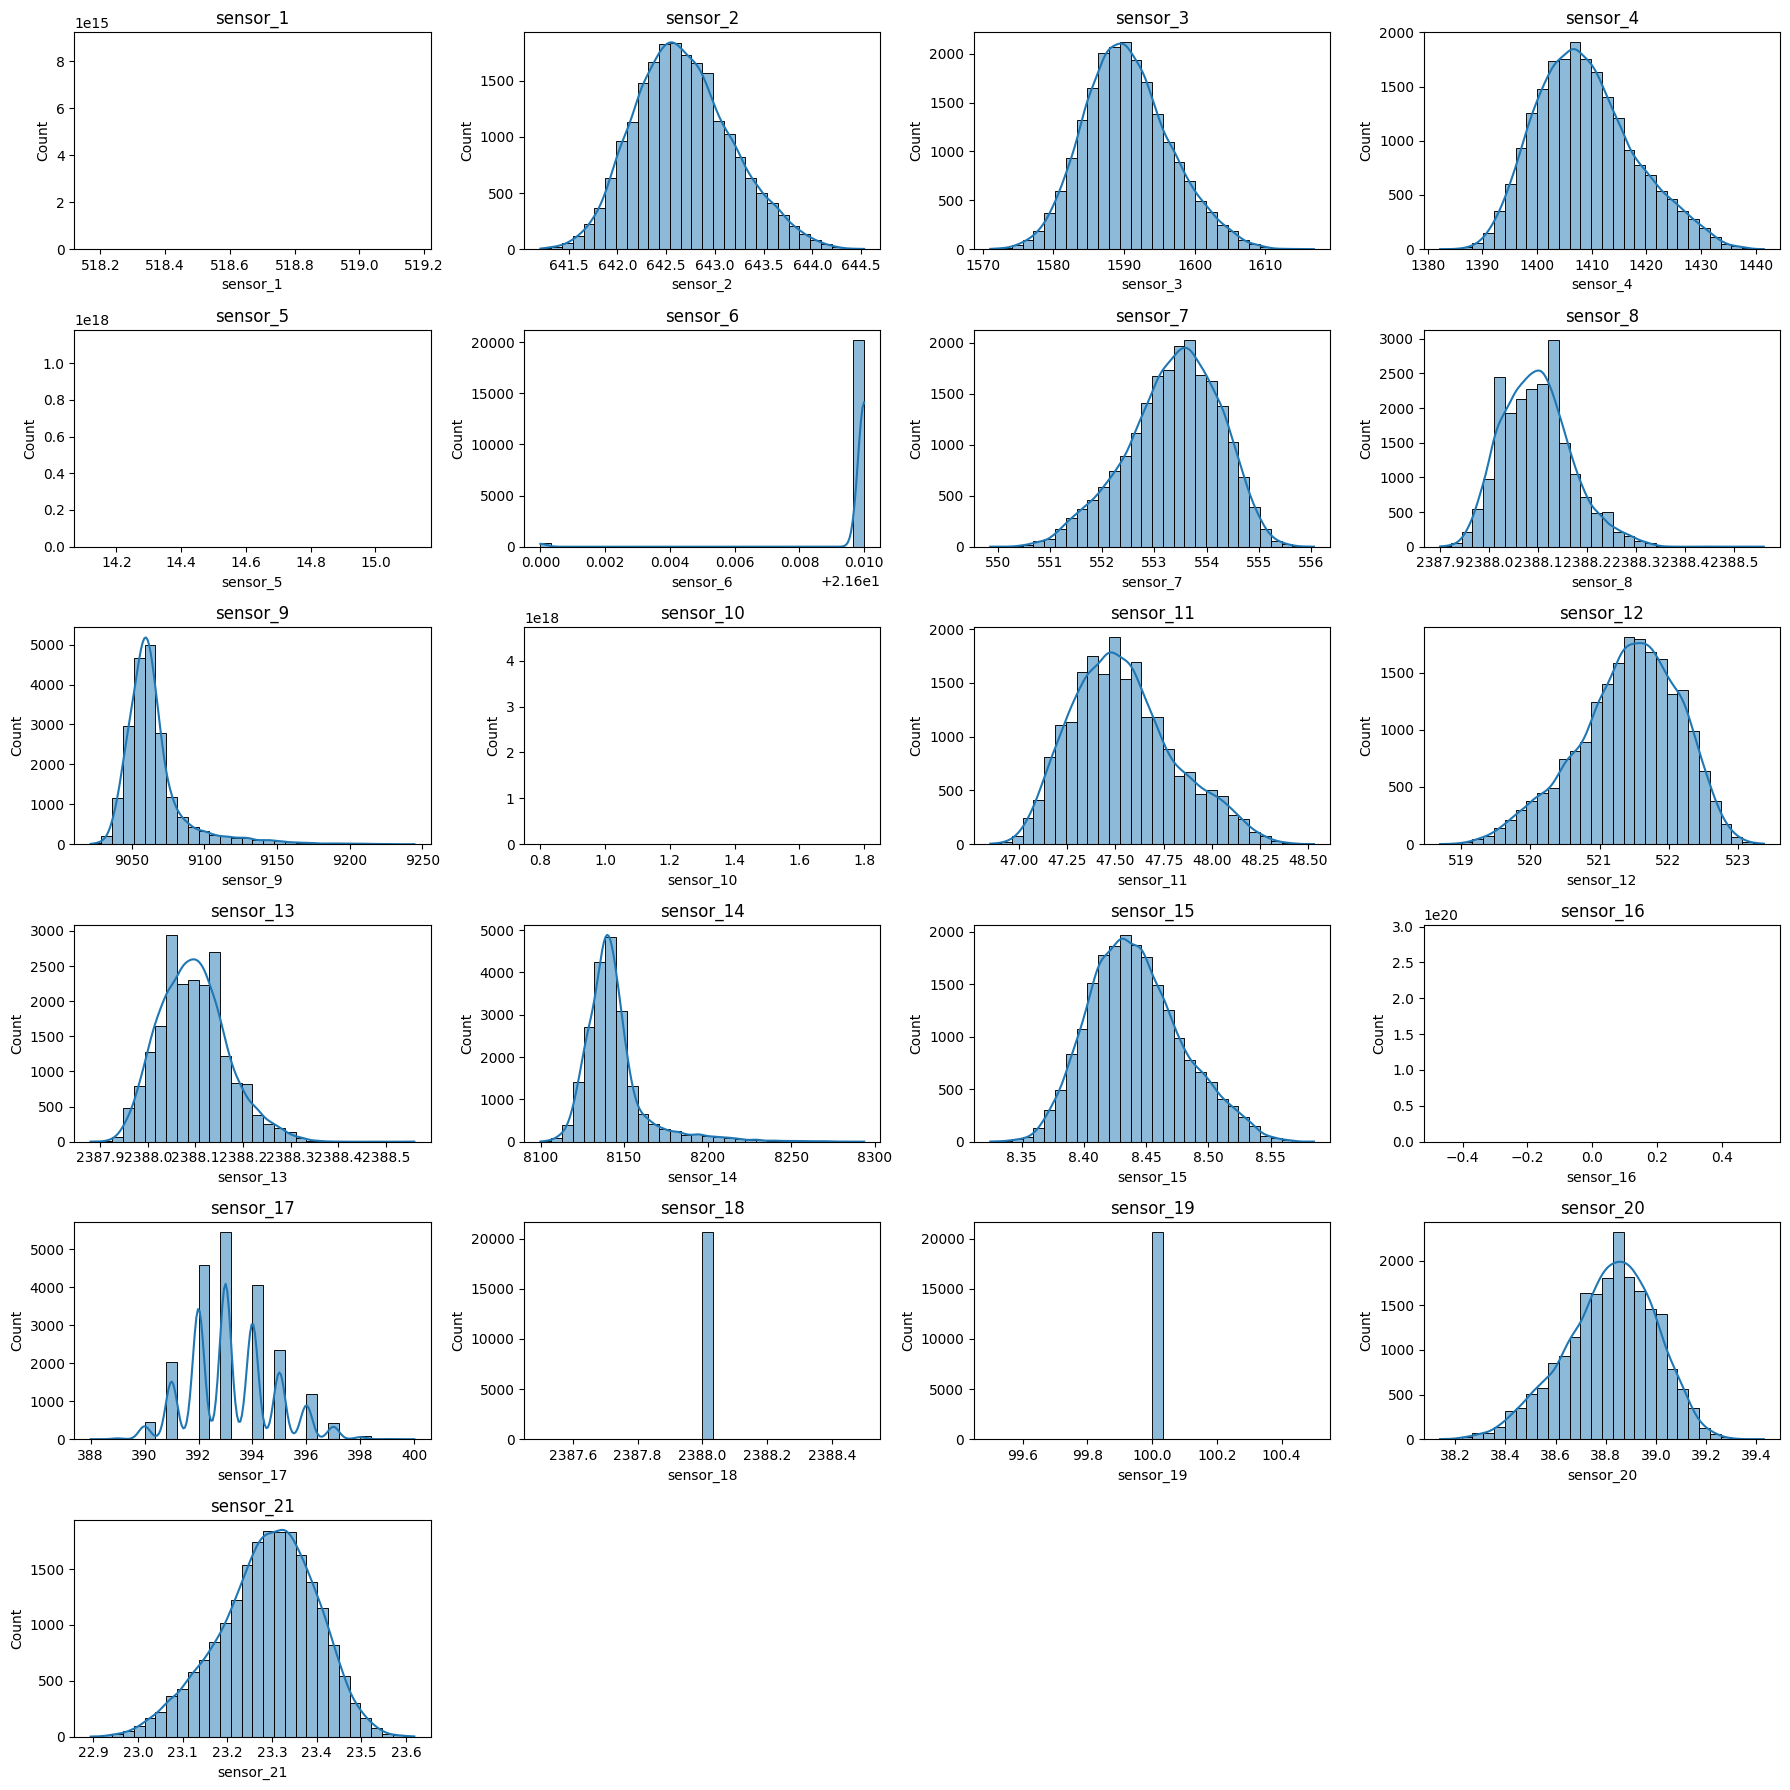

In [225]:
#Distribución de un sensor
sensores = [col for col in df.columns if 'sensor' in col]

cols = 4
rows = (len(sensores) // cols) + 1

plt.figure(figsize=(18, rows * 3))

for i, col in enumerate(sensores):
    plt.subplot(rows, cols, i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

**Analisis Bivariado**

In [226]:
# Filtrar solo sensores
sensores = [col for col in df.columns if 'sensor' in col]

# Correlacion solo sensores vs vida útil
corr_vida = df[sensores + ['vida_util']].corr()['vida_util']

# Eliminar NaN
corr_vida = corr_vida.dropna()

# Ordenar
corr_vida = corr_vida.sort_values()

# Mostrar top sensores
top_sensores = corr_vida.tail(5).index.tolist()
print(top_sensores)

['sensor_20', 'sensor_21', 'sensor_7', 'sensor_12', 'vida_util']


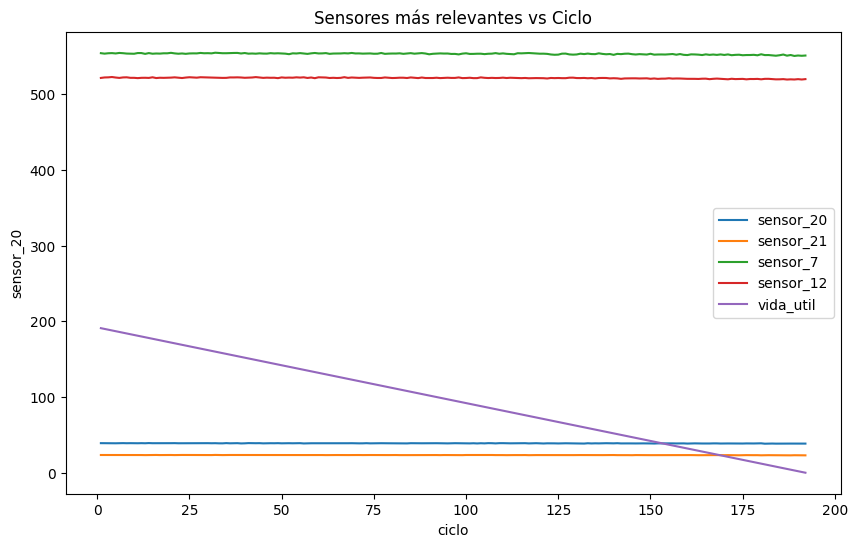

In [227]:
# Sensores (mas importantes) vs ciclo
plt.figure(figsize=(10,6))

for sensor in top_sensores:
    sns.lineplot(
        data=df[df['motor_id']==1],
        x='ciclo',
        y=sensor,
        label=sensor
    )

plt.title("Sensores más relevantes vs Ciclo")
plt.legend()
plt.show()

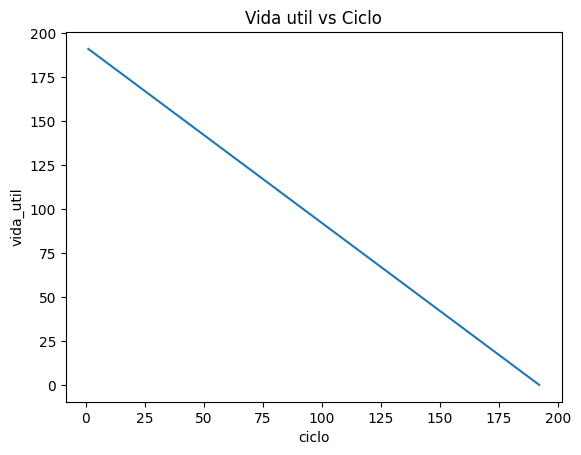

In [228]:
#Vida util vs ciclo
sns.lineplot(data=df[df['motor_id']==1], x='ciclo', y='vida_util')
plt.title("Vida util vs Ciclo")
plt.show()

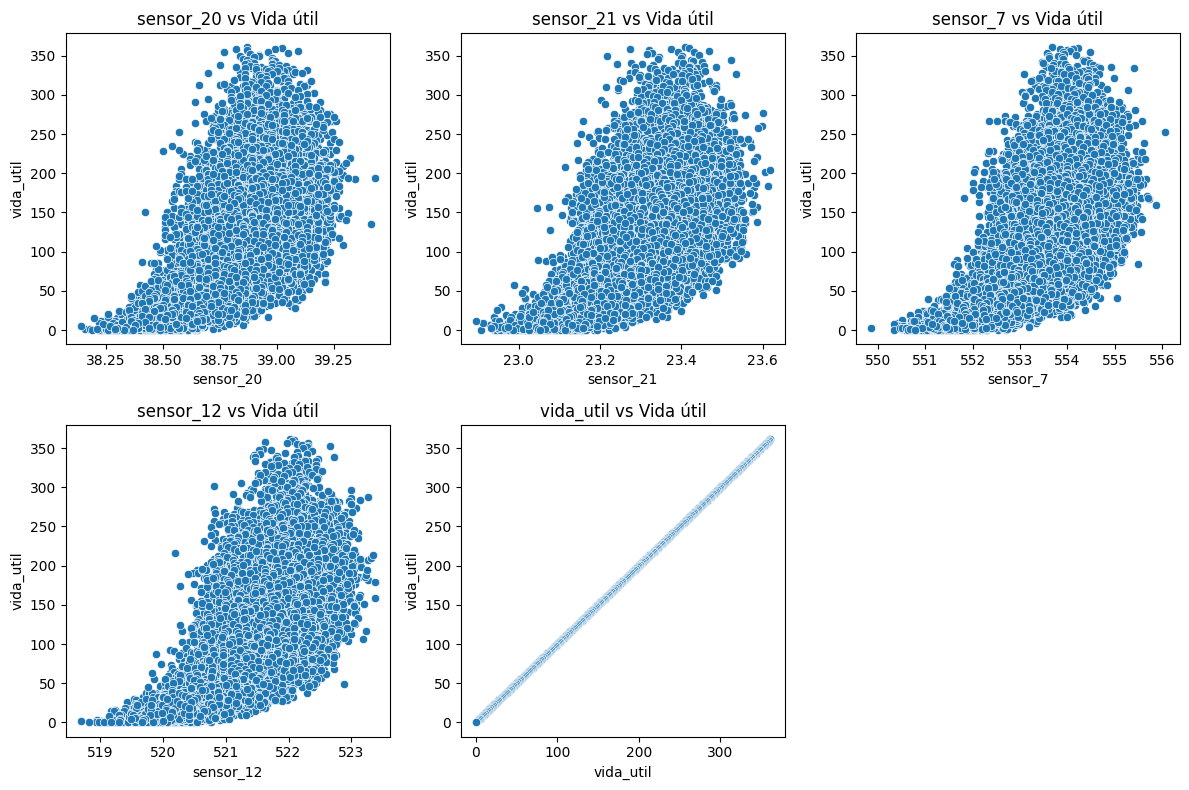

In [229]:
#Relacion directa - Sensor vs Vida útil
plt.figure(figsize=(12,8))

for i, sensor in enumerate(top_sensores):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=df[sensor], y=df['vida_util'])
    plt.title(f"{sensor} vs Vida útil")

plt.tight_layout()
plt.show()

**Analisis Multivariado**

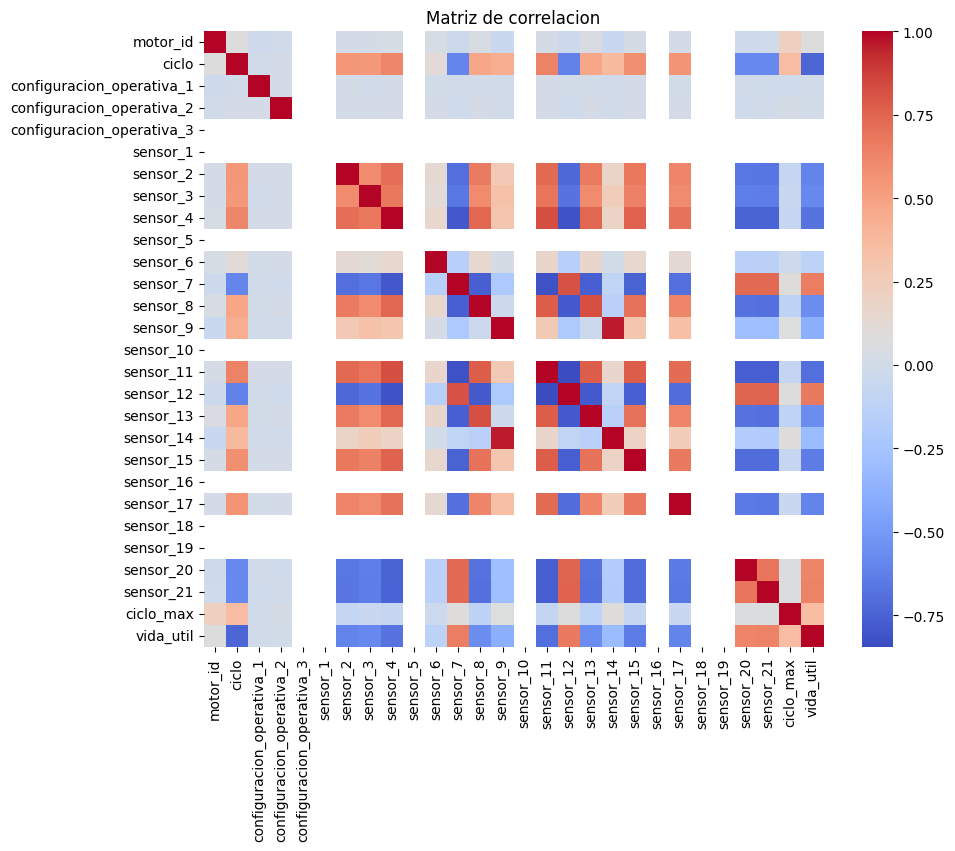

In [230]:
# Matriz de correlacion
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Matriz de correlacion")
plt.show()

##DESCRIPCIÓN GENERAL DEL EDA

El analisis exploratorio muestra que la vida util disminuye con el uso del motor y presenta una mayor concentración en valores bajos.

Los sensores presentan comportamientos variados: algunos son estables y otros muestran mayor variabilidad y posibles valores atipicos.

A partir de la correlación, se identifican los sensores más relevantes, los cuales permiten entender mejor el desgaste del motor y serán clave para el modelo.

##HALLAZGOS (INSIGHTS)

1. La vida util disminuye progresivamente a medida que aumentan los ciclos.

2. Algunos sensores presentan cambios consistentes antes de la falla,
   lo que indica su utilidad para prediccion.

3. Existen variables con alta correlación con la vida util,
   lo que sugiere que pueden ser utilizadas en modelos predictivos.

4. Se observan patrones repetitivos de degradación en distintos motores,
   lo cual valida la posibilidad de generalizar modelos.

##CONCLUSIÓN FINAL

El analisis permitio identificar patrones de degradación en motores
a partir de sensores.

Se logro construir una variable objetivo (vida util) y detectar
variables relevantes para su prediccion.

Este tipo de modelos puede aplicarse en entornos reales para implementar
mantenimiento predictivo, reduciendo costos y mejorando la eficiencia operativa.